In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

try:
    from scipy.interpolate import interp1d
    SCIPY_DISPONIVEL = True
except ImportError:
    SCIPY_DISPONIVEL = False

In [2]:
# ============================================================
# Metodo 1: Serie de Leibniz
# ============================================================
def pi_leibniz(n):
    soma = 0.0

    for k in range(n):
        soma += (-1)**k / (2*k + 1)

    return 4 * soma

In [3]:
# ============================================================
# Metodo 2: Serie de Nilakantha
# ============================================================
def pi_nilakantha(n):
    pi = 3.0

    for k in range(1, n + 1):
        sinal = (-1)**(k + 1)
        denominador = (2*k) * (2*k + 1) * (2*k + 2)
        pi += sinal * 4 / denominador

    return pi

In [4]:
# ============================================================
# Metodo 3: Monte Carlo
# ============================================================
def pi_monte_carlo(n, semente=42):
    random.seed(semente)

    dentro = 0

    for i in range(n):
        x = random.random()
        y = random.random()

        if x**2 + y**2 <= 1:
            dentro += 1

    return 4 * dentro / n

In [5]:
# ============================================================
# Metodo 4: Formula de Machin com serie do arctan
# ============================================================
def arctan_serie(x, n):
    soma = 0.0

    for k in range(n):
        soma += (-1)**k * x**(2*k + 1) / (2*k + 1)

    return soma

def pi_machin(n):
    return 16 * arctan_serie(1/5, n) - 4 * arctan_serie(1/239, n)

In [6]:
# ============================================================
# Metodo 5: Chudnovsky
# ============================================================
def pi_chudnovsky(n):
    soma = 0.0

    for k in range(n):
        numerador = (-1)**k * math.factorial(6*k) * (13591409 + 545140134*k)
        denominador = math.factorial(3*k) * (math.factorial(k)**3) * (640320**(3*k))
        soma += numerador / denominador

    pi = 426880 * math.sqrt(10005) / soma

    return pi

In [7]:
def interpolar_curva(N_original, pi_original, N_novo):

    N_original = np.asarray(N_original, dtype=float)
    pi_original = np.asarray(pi_original, dtype=float)

    ordem = np.argsort(N_original)
    N_original = N_original[ordem]
    pi_original = pi_original[ordem]

    logN_original = np.log10(N_original)
    logN_novo = np.log10(N_novo)

    if SCIPY_DISPONIVEL:
        f = interp1d(
            logN_original,
            pi_original,
            kind="linear",
            bounds_error=False,
            fill_value=(pi_original[0], pi_original[-1])
        )
        return f(logN_novo)

    return np.interp(
        logN_novo,
        logN_original,
        pi_original,
        left=pi_original[0],
        right=pi_original[-1]
    )

In [8]:
# ENTRADAS DE CADA METODO

N_leibniz = [10, 30, 100, 300, 1000, 3000, 10000, 30000, 100000, 300000, 1000000]
N_nilakantha = [1, 3, 10, 30, 100, 300, 1000, 3000, 10000, 30000, 100000, 300000, 1000000]
N_monte_carlo = [100, 300, 1000, 3000, 10000, 30000, 100000, 300000, 1000000]
N_machin = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
N_chudnovsky = [1, 2, 3, 4, 5, 6, 7]

In [9]:
# EXECUCAO SEPARADA DE CADA METODO

# Leibniz
pi_leibniz_resultados = [pi_leibniz(n) for n in N_leibniz]

# Nilakantha
pi_nilakantha_resultados = [pi_nilakantha(n) for n in N_nilakantha]

# Monte Carlo
pi_monte_carlo_resultados = [pi_monte_carlo(n) for n in N_monte_carlo]

# Machin
pi_machin_resultados = [pi_machin(n) for n in N_machin]

# Chudnovsky
pi_chudnovsky_resultados = [pi_chudnovsky(n) for n in N_chudnovsky]

In [10]:
PI_REF = math.pi
print("Valor de referencia de pi:", PI_REF)
print()

Valor de referencia de pi: 3.141592653589793



In [11]:
print("Metodo de Leibniz")
for n, valor in zip(N_leibniz, pi_leibniz_resultados):
    print(f"N = {n:<10} pi = {valor:.15f}")
print()

Metodo de Leibniz
N = 10         pi = 3.041839618929403
N = 30         pi = 3.108268566698947
N = 100        pi = 3.131592903558554
N = 300        pi = 3.138259329515591
N = 1000       pi = 3.140592653839794
N = 3000       pi = 3.141259320265719
N = 10000      pi = 3.141492653590034
N = 30000      pi = 3.141559320256462
N = 100000     pi = 3.141582653589720
N = 300000     pi = 3.141589320256464
N = 1000000    pi = 3.141591653589774



In [12]:
print("Metodo de Nilakantha")
for n, valor in zip(N_nilakantha, pi_nilakantha_resultados):
    print(f"N = {n:<10} pi = {valor:.15f}")
print()

Metodo de Nilakantha
N = 1          pi = 3.166666666666667
N = 3          pi = 3.145238095238095
N = 10         pi = 3.141406718496502
N = 30         pi = 3.141584272674621
N = 100        pi = 3.141592410971982
N = 300        pi = 3.141592644422639
N = 1000       pi = 3.141592653340544
N = 3000       pi = 3.141592653580549
N = 10000      pi = 3.141592653589538
N = 30000      pi = 3.141592653589777
N = 100000     pi = 3.141592653589786
N = 300000     pi = 3.141592653589787
N = 1000000    pi = 3.141592653589787



In [13]:
print("Metodo de Monte Carlo")
for n, valor in zip(N_monte_carlo, pi_monte_carlo_resultados):
    print(f"N = {n:<10} pi = {valor:.15f}")
print()

Metodo de Monte Carlo
N = 100        pi = 3.120000000000000
N = 300        pi = 3.133333333333333
N = 1000       pi = 3.128000000000000
N = 3000       pi = 3.162666666666667
N = 10000      pi = 3.126000000000000
N = 30000      pi = 3.134266666666667
N = 100000     pi = 3.137280000000000
N = 300000     pi = 3.141213333333333
N = 1000000    pi = 3.140592000000000



In [14]:
print("Metodo de Machin")
for n, valor in zip(N_machin, pi_machin_resultados):
    print(f"N = {n:<10} pi = {valor:.15f}")
print()

Metodo de Machin
N = 1          pi = 3.183263598326360
N = 2          pi = 3.140597029326060
N = 3          pi = 3.141621029325035
N = 4          pi = 3.141591772182177
N = 5          pi = 3.141592682404399
N = 6          pi = 3.141592652615309
N = 7          pi = 3.141592653623555
N = 8          pi = 3.141592653588603
N = 9          pi = 3.141592653589836
N = 10         pi = 3.141592653589792



In [15]:
print("Metodo de Chudnovsky")
for n, valor in zip(N_chudnovsky, pi_chudnovsky_resultados):
    print(f"N = {n:<10} pi = {valor:.15f}")
print()

Metodo de Chudnovsky
N = 1          pi = 3.141592653589734
N = 2          pi = 3.141592653589793
N = 3          pi = 3.141592653589793
N = 4          pi = 3.141592653589793
N = 5          pi = 3.141592653589793
N = 6          pi = 3.141592653589793
N = 7          pi = 3.141592653589793



In [16]:
X_MIN = np.min(N_leibniz)
X_MAX = np.max(N_leibniz)

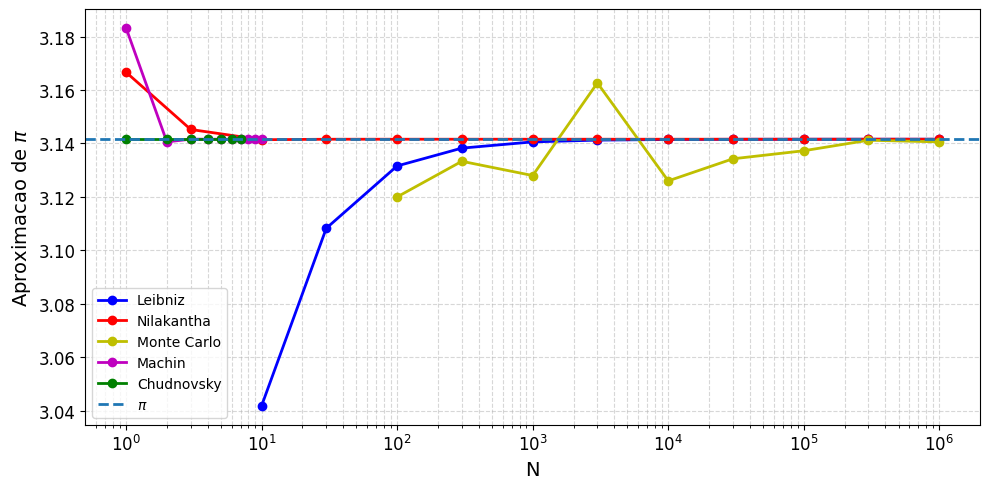

In [17]:
plt.figure(figsize=(10, 5))

plt.plot(N_leibniz, pi_leibniz_resultados, "bo-", linewidth=2, label="Leibniz")
plt.plot(N_nilakantha, pi_nilakantha_resultados, "ro-", linewidth=2, label="Nilakantha")
plt.plot(N_monte_carlo, pi_monte_carlo_resultados, "yo-", linewidth=2, label="Monte Carlo")
plt.plot(N_machin, pi_machin_resultados, "mo-", linewidth=2, label="Machin")
plt.plot(N_chudnovsky, pi_chudnovsky_resultados, "go-", linewidth=2, label="Chudnovsky")

plt.axhline(PI_REF, linestyle="--", linewidth=2, label="$\pi$")

plt.xscale("log")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("N", fontsize=14)
plt.ylabel("Aproximacao de $\pi$", fontsize = 14)
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()

plt.savefig("figura_01_convergencia_geral.png", dpi=600, bbox_inches="tight")
plt.show()

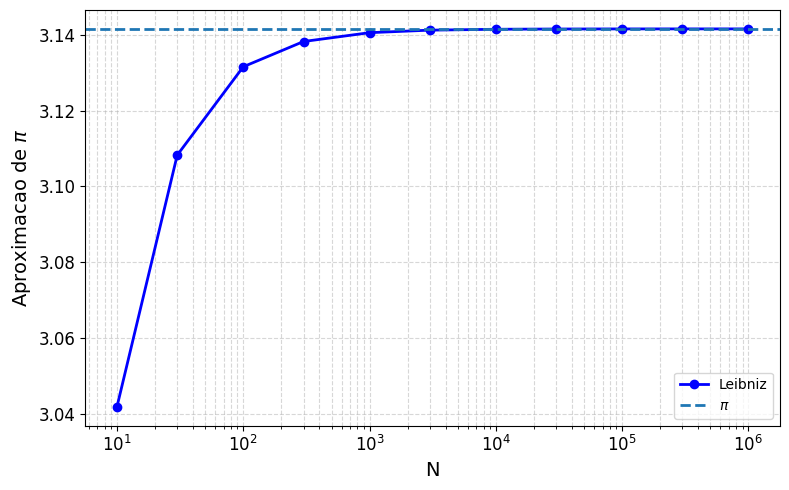

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(N_leibniz, pi_leibniz_resultados, "bo-", linewidth=2, label="Leibniz")
#plt.plot(N_nilakantha, pi_nilakantha_resultados, "ro-", linewidth=2, label="Nilakantha")
#plt.plot(N_monte_carlo, pi_monte_carlo_resultados, "yo-", linewidth=2, label="Monte Carlo")
#plt.plot(N_machin, pi_machin_resultados, "mo-", linewidth=2, label="Machin")
#plt.plot(N_chudnovsky, pi_chudnovsky_resultados, "go-", linewidth=2, label="Chudnovsky")

plt.axhline(PI_REF, linestyle="--", linewidth=2, label="$\pi$")

plt.xscale("log")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("N", fontsize=14)
plt.ylabel("Aproximacao de $\pi$", fontsize = 14)
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()

plt.savefig("figura_02_leibniz.png", dpi=600, bbox_inches="tight")
plt.show()

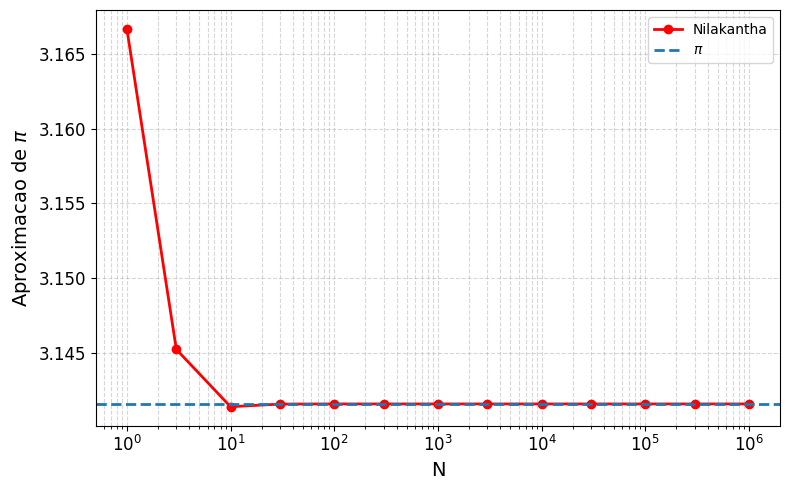

In [19]:
plt.figure(figsize=(8, 5))

#plt.plot(N_leibniz, pi_leibniz_resultados, "bo-", linewidth=2, label="Leibniz")
plt.plot(N_nilakantha, pi_nilakantha_resultados, "ro-", linewidth=2, label="Nilakantha")
#plt.plot(N_monte_carlo, pi_monte_carlo_resultados, "yo-", linewidth=2, label="Monte Carlo")
#plt.plot(N_machin, pi_machin_resultados, "mo-", linewidth=2, label="Machin")
#plt.plot(N_chudnovsky, pi_chudnovsky_resultados, "go-", linewidth=2, label="Chudnovsky")

plt.axhline(PI_REF, linestyle="--", linewidth=2, label="$\pi$")

plt.xscale("log")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("N", fontsize=14)
plt.ylabel("Aproximacao de $\pi$", fontsize = 14)
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()

plt.savefig("figura_03_nilakantha.png", dpi=600, bbox_inches="tight")
plt.show()

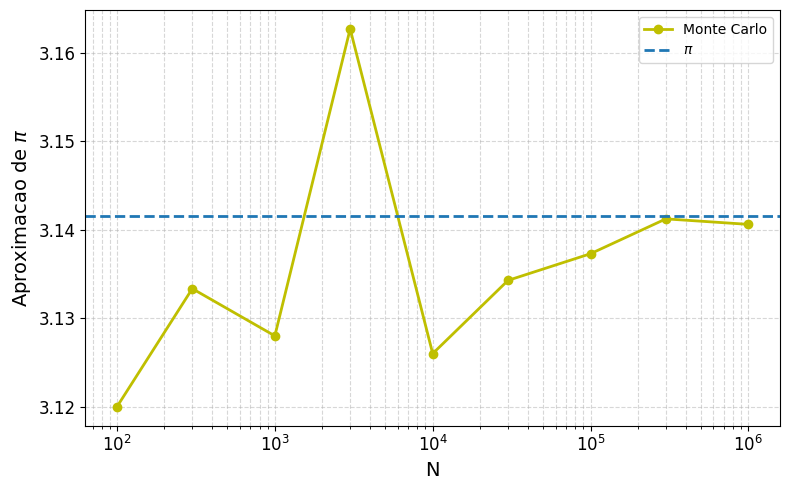

In [20]:
plt.figure(figsize=(8, 5))

#plt.plot(N_leibniz, pi_leibniz_resultados, "bo-", linewidth=2, label="Leibniz")
#plt.plot(N_nilakantha, pi_nilakantha_resultados, "ro-", linewidth=2, label="Nilakantha")
plt.plot(N_monte_carlo, pi_monte_carlo_resultados, "yo-", linewidth=2, label="Monte Carlo")
#plt.plot(N_machin, pi_machin_resultados, "mo-", linewidth=2, label="Machin")
#plt.plot(N_chudnovsky, pi_chudnovsky_resultados, "go-", linewidth=2, label="Chudnovsky")

plt.axhline(PI_REF, linestyle="--", linewidth=2, label="$\pi$")

plt.xscale("log")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("N", fontsize=14)
plt.ylabel("Aproximacao de $\pi$", fontsize = 14)
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()

plt.savefig("figura_04_montecarlo.png", dpi=600, bbox_inches="tight")
plt.show()

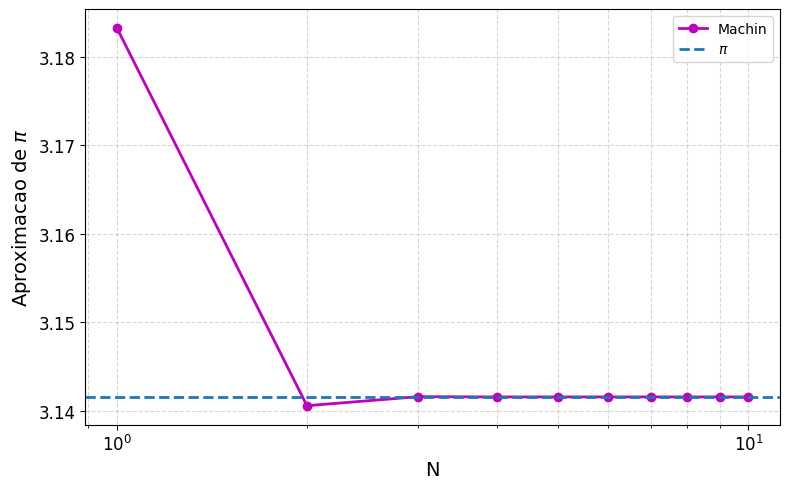

In [21]:
plt.figure(figsize=(8, 5))

#plt.plot(N_leibniz, pi_leibniz_resultados, "bo-", linewidth=2, label="Leibniz")
#plt.plot(N_nilakantha, pi_nilakantha_resultados, "ro-", linewidth=2, label="Nilakantha")
#plt.plot(N_monte_carlo, pi_monte_carlo_resultados, "yo-", linewidth=2, label="Monte Carlo")
plt.plot(N_machin, pi_machin_resultados, "mo-", linewidth=2, label="Machin")
#plt.plot(N_chudnovsky, pi_chudnovsky_resultados, "go-", linewidth=2, label="Chudnovsky")

plt.axhline(PI_REF, linestyle="--", linewidth=2, label="$\pi$")

plt.xscale("log")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("N", fontsize=14)
plt.ylabel("Aproximacao de $\pi$", fontsize = 14)
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()

plt.savefig("figura_05_machin.png", dpi=600, bbox_inches="tight")
plt.show()

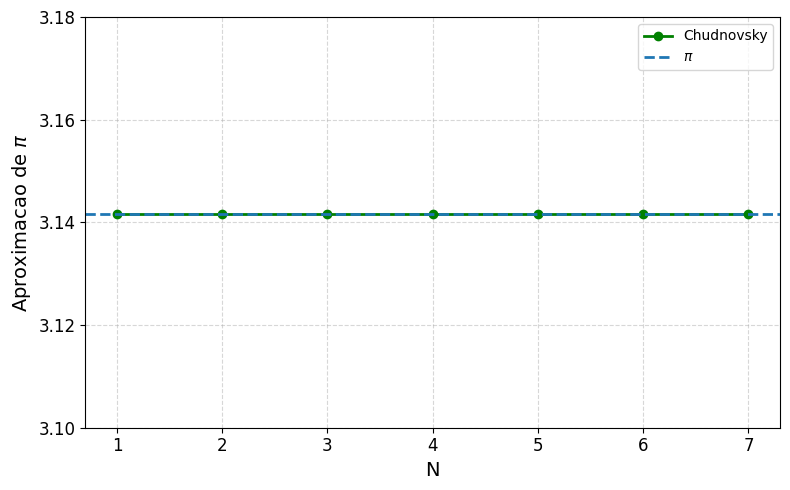

In [28]:
plt.figure(figsize=(8, 5))

#plt.plot(N_leibniz, pi_leibniz_resultados, "bo-", linewidth=2, label="Leibniz")
#plt.plot(N_nilakantha, pi_nilakantha_resultados, "ro-", linewidth=2, label="Nilakantha")
#plt.plot(N_monte_carlo, pi_monte_carlo_resultados, "yo-", linewidth=2, label="Monte Carlo")
#plt.plot(N_machin, pi_machin_resultados, "mo-", linewidth=2, label="Machin")
plt.plot(N_chudnovsky, pi_chudnovsky_resultados, "go-", linewidth=2, label="Chudnovsky")

plt.axhline(PI_REF, linestyle="--", linewidth=2, label="$\pi$")

#plt.xscale("log")
plt.xticks(fontsize=12)
plt.yticks(np.arange(3.10, 3.18, 0.02), fontsize=12)
plt.xlabel("N", fontsize=14)
plt.ylabel("Aproximacao de $\pi$", fontsize = 14)
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()

plt.savefig("figura_06_chudnovsky.png", dpi=600, bbox_inches="tight")
plt.show()